In [88]:
!./venv/bin/pip install crucio lime shap



[notice] A new release of pip is available: 26.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [89]:
from itertools import combinations
from typing import Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, StratifiedKFold, learning_curve, train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.base import clone
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve

from crucio import SMOTEENN
from lime import lime_tabular

from IPython.display import display, HTML
from shap import Explainer, plots, initjs, maskers

RANDOM_STATE = 42
TARGET_COL = 'Outcome'

LEAKAGE_COLS = [
    "NS1",
    "IgG",
    "IgM",
    "Platelet_Count",
    "WBC_Count",
    "Body_Temperature",
    "Fever_Duration",
]

CATEGORICAL_COLS = ["Gender", "AreaType", "HouseType", "Joint_Pain"]
OUTLIER_PARAMS = {"n_neighbors": 20, "leaf_size": 30, "contamination": 0.05}


In [90]:
# Load dataset and inspect columns
poverty = pd.read_csv("area_poverty_table.csv")
df = pd.read_csv("data.csv")
df = df.rename(columns=lambda x: x.strip())
df = df.drop(columns=[col for col in LEAKAGE_COLS + ["District"] if col in df.columns])
df["Area_HCR"] = df["Area"].map(poverty.set_index("Area")["HCR_upper_2022"])
df.head()


,Gender,Age,Area,AreaType,HouseType,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome,Area_HCR
0,Female,45,Mirpur,Undeveloped,Building,Severe,0,0,1,0.0000,0,12.6000
1,Male,17,Chawkbazar,Developed,Building,NaN,1,0,0,0.0000,0,7.5000
2,Female,29,Paltan,Undeveloped,Other,NaN,0,0,0,0.0000,0,1.0000
3,Female,63,Motijheel,Developed,Other,Moderate,0,0,1,0.0000,1,3.6000
4,Male,22,Gendaria,Undeveloped,Building,NaN,0,0,0,0.0000,0,2.4000


In [91]:
N_COMPONENTS = 5


In [92]:
def apply_outlier_filter(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    random_state: int = RANDOM_STATE,
) -> Tuple[pd.DataFrame, pd.Series]:
    detector = LocalOutlierFactor(**OUTLIER_PARAMS)
    labels = detector.fit_predict(X_train)
    mask = pd.Series(labels == 1, index=X_train.index)
    X_filtered = X_train.loc[mask].copy()
    y_filtered = y_train.loc[mask].copy()
    return X_filtered, y_filtered


In [93]:
def prepare_features(df: pd.DataFrame, reference: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["Joint_Pain"] = out["Joint_Pain"].fillna("None")
    for col in out.select_dtypes(include="number"):
        out[col] = out[col].fillna(reference[col].median())
    for col in CATEGORICAL_COLS:
        out[col] = out[col].fillna(reference[col].mode()[0])
    return pd.get_dummies(out, columns=CATEGORICAL_COLS, drop_first=True, dtype=int)


def split_train_val_test(df: pd.DataFrame, random_state: int = RANDOM_STATE) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df_dev, df_test = train_test_split(df, test_size=0.1, random_state=random_state)
    df_train, df_val = train_test_split(df_dev, test_size=1 / 9, random_state=random_state)
    return df_train, df_val, df_test


In [94]:
def add_area_binning(df: pd.DataFrame, poverty_df: pd.DataFrame, n_bins: int = 5) -> pd.DataFrame:
    out = df.copy()
    areas = (
        out[["Area", "Outcome"]]
        .dropna(subset=["Area"])
        .groupby("Area", as_index=False)
        .agg(n_patients=("Outcome", "size"))
        .merge(poverty_df[["Area", "HCR_upper_2022"]], on="Area", how="left")
        .sort_values(["HCR_upper_2022", "Area"], kind="mergesort")
        .reset_index(drop=True)
    )

    def find_balanced_cuts(sizes, n_bins=5):
        sizes = np.asarray(sizes, dtype=float)
        cumulative = np.concatenate([[0], sizes.cumsum()])
        target = sizes.sum() / n_bins
        best_score, best_bounds = None, None
        for cuts in combinations(range(1, len(sizes)), n_bins - 1):
            bounds = (0,) + cuts + (len(sizes),)
            counts = np.diff(cumulative[list(bounds)])
            deviations = np.abs(counts - target)
            score = (deviations.max(), (deviations ** 2).sum())
            if best_score is None or score < best_score:
                best_score, best_bounds = score, bounds
        return list(best_bounds), best_score

    bounds, _ = find_balanced_cuts(areas["n_patients"].values, n_bins=n_bins)
    inner_edges = [
        round((areas.loc[b - 1, "HCR_upper_2022"] + areas.loc[b, "HCR_upper_2022"]) / 2, 3)
        for b in bounds[1:-1]
    ]
    bin_edges = [-np.inf] + inner_edges + [np.inf]
    bin_labels = [f"Q{i}" for i in range(1, n_bins + 1)]
    area_to_hcr = poverty_df.set_index("Area")["HCR_upper_2022"]
    out["Area_HCR"] = out["Area"].map(area_to_hcr)
    out["Area_bin"] = pd.cut(out["Area_HCR"], bins=bin_edges, labels=bin_labels, ordered=True)
    out["Area_bin_code"] = out["Area_bin"].cat.codes
    out = out.drop(columns=["Area_bin", "Area_HCR"])
    return out


def add_age_binning(df: pd.DataFrame, balance_tolerance: float = 0.10) -> pd.DataFrame:
    out = df.copy()
    age_counts = (
        out.groupby("Age")
        .agg(n_patients=("Outcome", "size"), positive_rate=("Outcome", "mean"))
        .sort_index()
    )

    def enumerate_splits(n_groups, n_bins):
        return np.array(
            [(0,) + cuts + (n_groups,) for cuts in combinations(range(1, n_groups), n_bins - 1)],
            dtype=np.int32,
        )

    def score_splits(splits, group_sizes, group_positives):
        group_sizes = np.asarray(group_sizes, dtype=float)
        group_positives = np.asarray(group_positives, dtype=float)
        cum_n = np.concatenate([[0], group_sizes.cumsum()])
        cum_p = np.concatenate([[0], group_positives.cumsum()])
        n = np.diff(cum_n[splits], axis=1)
        p = np.diff(cum_p[splits], axis=1)
        total_n, total_p = group_sizes.sum(), group_positives.sum()
        target = total_n / (splits.shape[1] - 1)
        expected_pos = n * total_p / total_n
        expected_neg = n * (total_n - total_p) / total_n
        with np.errstate(divide="ignore", invalid="ignore"):
            chi2 = np.nan_to_num(
                (p - expected_pos) ** 2 / expected_pos + ((n - p) - expected_neg) ** 2 / expected_neg
            ).sum(axis=1)
        rates = np.divide(p, n, out=np.full_like(p, np.nan), where=n > 0)
        return {
            "n": n,
            "rates": rates,
            "balance_deviation": np.abs(n - target).max(axis=1),
            "rate_spread": np.nanmax(rates, axis=1) - np.nanmin(rates, axis=1),
            "chi2": chi2,
        }

    age_values = age_counts.index.to_numpy()
    age_sizes = age_counts["n_patients"].to_numpy()
    age_positives = out.groupby("Age")["Outcome"].sum().sort_index().to_numpy()
    splits = enumerate_splits(len(age_values), 5)
    scores = score_splits(splits, age_sizes, age_positives)
    tol = balance_tolerance * len(out) / 5
    allowed = np.where(scores["balance_deviation"] <= tol)[0]
    if len(allowed) == 0:
        raise ValueError("No age split satisfies the balance tolerance.")
    chosen = allowed[scores["chi2"][allowed].argmax()]
    age_bounds = splits[chosen]
    age_edges = [-np.inf] + [(age_values[b - 1] + age_values[b]) / 2 for b in age_bounds[1:-1]] + [np.inf]
    age_labels = [f"{age_values[age_bounds[i]]}-{age_values[age_bounds[i + 1] - 1]}" for i in range(5)]
    out["Age_bin"] = pd.cut(out["Age"], bins=age_edges, labels=age_labels, ordered=True)
    out = pd.get_dummies(out, columns=["Age_bin"], drop_first=True, dtype=int)
    return out


def apply_binning(df: pd.DataFrame) -> pd.DataFrame:
    df = add_area_binning(df, poverty)
    return add_age_binning(df)


In [95]:
def create_pca_data(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    n_components: int = N_COMPONENTS,
) -> Tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train_s)
    X_test_pca = pca.transform(X_test_s)
    return X_train_pca, X_test_pca


In [96]:
# Selected features per user request
SELECTED_FEATURES = [
    "Headache",
    "Retro_Orbital_Pain",
    "Myalgia",
    "Rash",
    "Joint_Pain_None",
    "Joint_Pain_Severe",
]


In [97]:
def build_fold_data(df_train_raw: pd.DataFrame, df_val_raw: pd.DataFrame):
    """Run the shared preparation steps on one train/validation pair."""
    # 1) Impute and one-hot encode using training statistics only (prevents leakage), then bin Area/Age
    df_train = apply_binning(prepare_features(df_train_raw, reference=df_train_raw))
    df_val = apply_binning(prepare_features(df_val_raw, reference=df_train_raw))

    X_train_raw = df_train.drop(columns=[TARGET_COL]).copy()
    y_train = df_train[TARGET_COL].copy()
    y_val = df_val[TARGET_COL].copy().reset_index(drop=True)

    # 2) Select features; if any missing, fill with zeros (shouldn't happen)
    X_train_raw = X_train_raw.reindex(columns=SELECTED_FEATURES, fill_value=0)
    X_val_sel = df_val.reindex(columns=SELECTED_FEATURES, fill_value=0).reset_index(drop=True)

    # 3) Apply outlier filtering on the selected training features
    X_train_f, y_train_f = apply_outlier_filter(X_train_raw, y_train, random_state=RANDOM_STATE)
    X_train_sel = X_train_f.reset_index(drop=True)

    # 4) Balance the training fold with SMOTEENN (Crucio API)
    proc_df = X_train_sel.copy()
    proc_df[TARGET_COL] = y_train_f.reset_index(drop=True).astype(int)
    balanced_df = SMOTEENN().balance(proc_df, TARGET_COL)
    X_train_balanced = balanced_df.drop(columns=[TARGET_COL]).reset_index(drop=True)
    y_train_balanced = balanced_df[TARGET_COL].astype(int).reset_index(drop=True)

    return X_train_balanced, y_train_balanced, X_val_sel, y_val


In [98]:
# Prepare data and models
X = df.drop(columns=[TARGET_COL]).copy()
y = df[TARGET_COL].copy()

model_candidates = {
    'GaussianNB': GaussianNB(),
    "CategoricalNB": CategoricalNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []

variant_builders = {
    'Engineered': lambda X_train_sel, X_val_sel: (X_train_sel, X_val_sel),
    f'PCA ({N_COMPONENTS} components)': lambda X_train_sel, X_val_sel: create_pca_data(
        X_train_sel, X_val_sel, n_components=N_COMPONENTS
    ),
}

# The preparation steps do not depend on the variant or the model, so run them once per fold
fold_data = [
    build_fold_data(df.iloc[train_idx].copy(), df.iloc[val_idx].copy())
    for train_idx, val_idx in kf.split(X)
]

for variant_name, variant_builder in variant_builders.items():
    for model_name, base_model in model_candidates.items():
        # CategoricalNB expects non-negative integer category codes, which PCA components are not
        if isinstance(base_model, CategoricalNB) and variant_name != 'Engineered':
            continue

        fold_recall = []
        fold_acc = []
        fold_prec = []
        fold_f1 = []

        for X_train_sel, y_train_sel, X_val_sel, y_val in fold_data:
            # 5) Build the comparison dataset: engineered or PCA(5)
            X_train_variant, X_val_variant = variant_builder(X_train_sel, X_val_sel)

            # 6) Fit model and evaluate
            model = clone(base_model)
            model.fit(X_train_variant, y_train_sel)
            y_pred = model.predict(X_val_variant)

            fold_recall.append(recall_score(y_val, y_pred, zero_division=0))
            fold_acc.append(accuracy_score(y_val, y_pred))
            fold_prec.append(precision_score(y_val, y_pred, zero_division=0))
            fold_f1.append(f1_score(y_val, y_pred, zero_division=0))

        rows.append({
            'Variant': variant_name,
            'Model': model_name,
            'Recall_mean': np.mean(fold_recall),
            'Recall_std': np.std(fold_recall),
            'Accuracy_mean': np.mean(fold_acc),
            'Accuracy_std': np.std(fold_acc),
            'Precision_mean': np.mean(fold_prec),
            'Precision_std': np.std(fold_prec),
            'F1_mean': np.mean(fold_f1),
            'F1_std': np.std(fold_f1),
        })

cv_results = pd.DataFrame(rows)
# Sort by main criteria: recall (desc), accuracy (desc), precision (desc), f1 (desc)
cv_results = cv_results.sort_values(
    ['Variant', 'Recall_mean', 'Accuracy_mean', 'Precision_mean', 'F1_mean'],
    ascending=[True, False, False, False, False],
).reset_index(drop=True)

pd.set_option('display.float_format', '{:.4f}'.format)
display(cv_results)

best_by_variant = (
    cv_results.sort_values(
        ['Recall_mean', 'Accuracy_mean', 'Precision_mean', 'F1_mean'],
        ascending=[False, False, False, False],
    )
    .groupby('Variant', as_index=False)
    .head(1)
    .reset_index(drop=True)
 )
display(best_by_variant)

for _, best in best_by_variant.iterrows():
    print(f"Variant: {best['Variant']}")
    print(f"Best model by primary metric (recall): {best['Model']}")
    print(f"Recall: {best['Recall_mean']:.4f} ± {best['Recall_std']:.4f}")
    print(f"Accuracy: {best['Accuracy_mean']:.4f} ± {best['Accuracy_std']:.4f}")
    print(f"Precision: {best['Precision_mean']:.4f} ± {best['Precision_std']:.4f}")
    print(f"F1: {best['F1_mean']:.4f} ± {best['F1_std']:.4f}")
    print('')


,Variant,Model,Recall_mean,Recall_std,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,F1_mean,F1_std
0,Engineered,GaussianNB,0.9717,0.0137,0.9370,0.0098,0.9152,0.0143,0.9425,0.0099
1,Engineered,RandomForest,0.9663,0.0203,0.9470,0.0282,0.9373,0.0335,0.9515,0.0255
2,Engineered,GradientBoosting,0.9663,0.0203,0.9410,0.0246,0.9275,0.0326,0.9462,0.0218
3,Engineered,CategoricalNB,0.9546,0.0147,0.9570,0.0103,0.9642,0.0104,0.9593,0.0104
4,Engineered,LogisticRegression,0.9529,0.0165,0.9610,0.0159,0.9730,0.0169,0.9628,0.0158
5,PCA (5 components),GaussianNB,0.9813,0.0084,0.9370,0.0144,0.9082,0.0228,0.9432,0.0130
6,PCA (5 components),GradientBoosting,0.9608,0.0234,0.9570,0.0186,0.9588,0.0155,0.9597,0.0178
7,PCA (5 components),RandomForest,0.9550,0.0235,0.9580,0.0186,0.9655,0.0162,0.9602,0.0183
8,PCA (5 components),LogisticRegression,0.9510,0.0147,0.9600,0.0152,0.9730,0.0169,0.9618,0.0151


,Variant,Model,Recall_mean,Recall_std,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,F1_mean,F1_std
0,PCA (5 components),GaussianNB,0.9813,0.0084,0.9370,0.0144,0.9082,0.0228,0.9432,0.0130
1,Engineered,GaussianNB,0.9717,0.0137,0.9370,0.0098,0.9152,0.0143,0.9425,0.0099


Variant: PCA (5 components)
Best model by primary metric (recall): GaussianNB
Recall: 0.9813 ± 0.0084
Accuracy: 0.9370 ± 0.0144
Precision: 0.9082 ± 0.0228
F1: 0.9432 ± 0.0130

Variant: Engineered
Best model by primary metric (recall): GaussianNB
Recall: 0.9717 ± 0.0137
Accuracy: 0.9370 ± 0.0098
Precision: 0.9152 ± 0.0143
F1: 0.9425 ± 0.0099



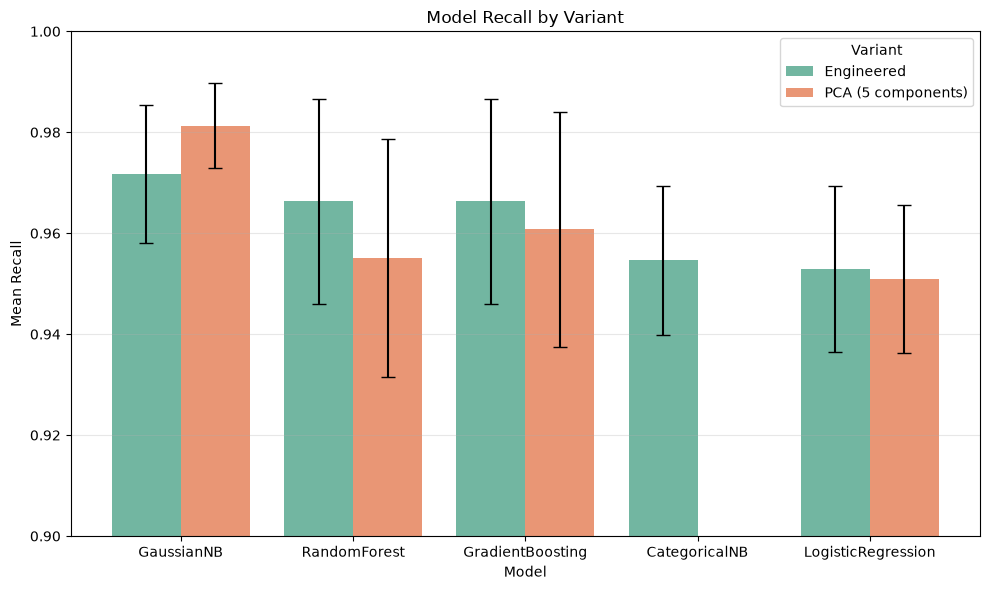

In [99]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=cv_results,
    x='Model',
    y='Recall_mean',
    hue='Variant',
    palette='Set2',
    capsize=0.1,
)

# Add standard deviation error bars manually
model_order = [tick.get_text() for tick in ax.get_xticklabels()]
for container, (_, group) in zip(ax.containers, cv_results.groupby('Variant')):
    # a variant may not run every model, and seaborn only draws bars for the pairs it has
    group = group.set_index('Model').reindex(model_order).dropna(subset=['Recall_mean'])
    ax.errorbar(
        x=[bar.get_x() + bar.get_width() / 2 for bar in container],
        y=group['Recall_mean'],
        yerr=group['Recall_std'],
        fmt='none',
        ecolor='black',
        elinewidth=1.5,
        capsize=5,
    )

plt.title('Model Recall by Variant')
plt.ylabel('Mean Recall')
plt.xlabel('Model')
plt.ylim(0.90, 1)
plt.legend(title='Variant')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Best variant / model: PCA (5 components) / GaussianNB


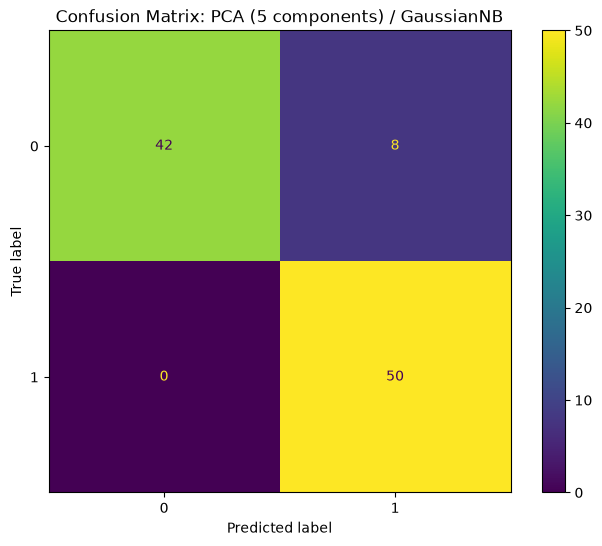

In [100]:
# confusion matrix from best model
df_train_raw, df_val_raw, _ = split_train_val_test(df, RANDOM_STATE)

X_train_sel, y_train_sel, X_val_sel, y_val = build_fold_data(df_train_raw, df_val_raw)

best = best_by_variant.loc[0]
X_train_variant, X_val_variant = variant_builders[best['Variant']](X_train_sel, X_val_sel)

best_model = clone(model_candidates[best['Model']])
best_model.fit(X_train_variant, y_train_sel)

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f"Confusion Matrix: {best['Variant']} / {best['Model']}")
print(f"Best variant / model: {best['Variant']} / {best['Model']}")
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_val_variant,
    y_val,
    ax=ax,
)


In [101]:
print(classification_report(y_val, best_model.predict(X_val_variant), zero_division=0))


              precision    recall  f1-score   support

           0       1.00      0.84      0.91        50
           1       0.86      1.00      0.93        50

    accuracy                           0.92       100
   macro avg       0.93      0.92      0.92       100
weighted avg       0.93      0.92      0.92       100



Best LogisticRegression variant: Engineered


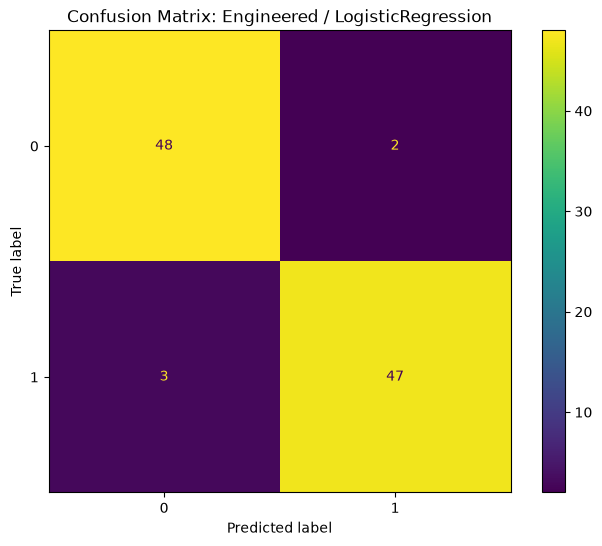

In [102]:

model = "LogisticRegression"
# confusion matrix from the best performing LogisticRegression model
best_lr = (
    cv_results[cv_results['Model'] == model]
    .sort_values(
        ['Recall_mean', 'Accuracy_mean', 'Precision_mean', 'F1_mean'],
        ascending=[False, False, False, False],
    )
    .iloc[0]
)

X_train_lr, X_val_lr = variant_builders[best_lr['Variant']](X_train_sel, X_val_sel)

lr_model = clone(model_candidates[model])
lr_model.fit(X_train_lr, y_train_sel)

print(f"Best {model} variant: {best_lr['Variant']}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title(f"Confusion Matrix: {best_lr['Variant']} / {model}")
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_val_lr,
    y_val,
    ax=ax
)


Best GaussianNB variant: PCA (5 components)


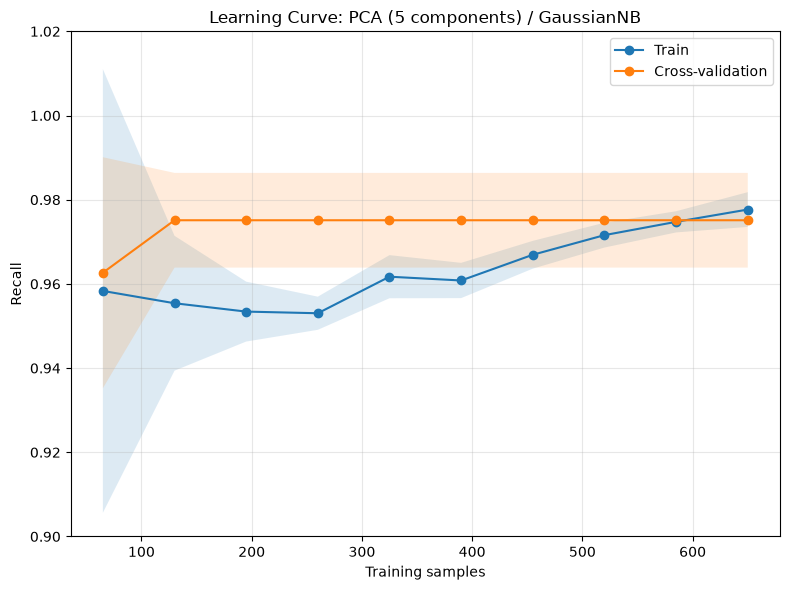

In [103]:
model = "GaussianNB"
# learning curve of the best performing GaussianNB model, scored by recall
best_gnb = (
    cv_results[cv_results['Model'] == model]
    .sort_values(
        ['Recall_mean', 'Accuracy_mean', 'Precision_mean', 'F1_mean'],
        ascending=[False, False, False, False],
    )
    .iloc[0]
)

# Same training split the models are fitted on above: outlier filtered, SMOTEENN balanced
X_train_gnb, X_val_gnb = variant_builders[best_gnb['Variant']](X_train_sel, X_val_sel)

print(f"Best {model} variant: {best_gnb['Variant']}")

train_sizes, train_scores, cv_scores = learning_curve(
    clone(model_candidates[model]),
    X_train_gnb,
    y_train_sel,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall',
    n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
cv_mean, cv_std = cv_scores.mean(axis=1), cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(train_sizes, train_mean, marker='o', label='Train')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.plot(train_sizes, cv_mean, marker='o', label='Cross-validation')
ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.15)
ax.set_title(f"Learning Curve: {best_gnb['Variant']} / {model}")
ax.set_xlabel('Training samples')
ax.set_ylabel('Recall')
ax.set_ylim(0.9, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [104]:
model = "GaussianNB"
variant = f'PCA ({N_COMPONENTS} components)'
# validation rows this model got wrong in the positive direction: actual 0, predicted 1

X_train_gnb, X_val_gnb = variant_builders[variant](X_train_sel, X_val_sel)

gnb_model = clone(model_candidates[model])
gnb_model.fit(X_train_gnb, y_train_sel)

y_val_pred = gnb_model.predict(X_val_gnb)
y_val_proba = gnb_model.predict_proba(X_val_gnb)[:, 1]

# build_fold_data keeps the row order of df_val_raw, so positions line up with the raw rows
false_positives = np.flatnonzero((y_val.to_numpy() == 0) & (y_val_pred == 1))

print(f"False positives for {variant} / {model}: {len(false_positives)} of {(y_val == 0).sum()} negatives")
display(
    df_val_raw.iloc[false_positives].assign(
        Predicted=y_val_pred[false_positives],
        Proba_Outcome_1=y_val_proba[false_positives],
    )
)


False positives for PCA (5 components) / GaussianNB: 8 of 50 negatives


,Gender,Age,Area,AreaType,HouseType,Joint_Pain,Headache,Retro_Orbital_Pain,Myalgia,Rash,Outcome,Area_HCR,Predicted,Proba_Outcome_1
311,Male,42,Jatrabari,Developed,Building,NaN,0,1,0,0.0000,0,9.4000,1,0.6320
997,Male,45,Motijheel,Developed,Building,NaN,0,1,0,0.0000,0,3.6000,1,0.6320
423,Male,38,Bangshal,Developed,Building,Severe,0,0,0,0.0000,0,4.2000,1,0.9933
757,Male,20,Pallabi,Developed,Building,NaN,1,1,0,1.0000,0,6.6000,1,0.9999
760,Male,24,Pallabi,Undeveloped,Building,Severe,1,0,0,0.0000,0,6.6000,1,1.0000
979,Male,64,Hazaribagh,Developed,Building,NaN,0,1,0,0.0000,0,6.3000,1,0.6320
638,Female,28,Khilkhet,Undeveloped,Tinshed,NaN,0,0,0,1.0000,0,7.7000,1,0.9685
26,Female,65,Gendaria,Undeveloped,Tinshed,NaN,0,1,0,0.0000,0,2.4000,1,0.6320


In [105]:
def plot_roc_curve(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

ROC AUC: 0.9902


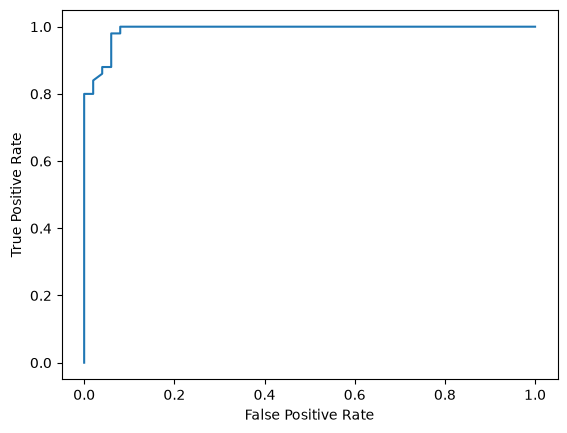

In [106]:
y_proba = gnb_model.predict_proba(X_val_gnb)[:, 1]
plot_roc_curve(y_val, y_proba)
print(f"ROC AUC: {roc_auc_score(y_val, y_proba):.4f}")

In [107]:
# LIME explanations on the validation split. The Engineered variant is used so the
# explanation is expressed in the original symptom features instead of PCA components.
lime_model = clone(model_candidates['GaussianNB'])
lime_model.fit(X_train_sel, y_train_sel)
lime_val_pred = lime_model.predict(X_val_sel)

feature_names = X_train_sel.columns.tolist()
# every selected feature is a 0/1 indicator, so all of them are categorical
categorical_feature_names = SELECTED_FEATURES

categorical_feature_indices = [
    feature_names.index(col) for col in categorical_feature_names if col in feature_names
]

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_sel.to_numpy(),
    feature_names=feature_names,
    categorical_features=categorical_feature_indices,
    training_labels=y_train_sel.to_numpy(),
    class_names=['No Dengue', 'Dengue'],
    verbose=True,
    mode="classification",
)


def lime_explain(index: int) -> None:
    instance = X_val_sel.iloc[index].to_numpy()
    exp = explainer.explain_instance(instance, lime_model.predict_proba)
    print(f"Actual value: {y_val.values[index]}")
    print(f"Predicted value: {lime_val_pred[index]}")
    display(HTML(exp.as_html(show_table=True, show_all=True)))


In [108]:
# explain one of the validation rows this model wrongly flagged as positive
lime_false_positives = np.flatnonzero((y_val.to_numpy() == 0) & (lime_val_pred == 1))
lime_explain(int(lime_false_positives[0]))

Intercept 1.1176479229566794
Prediction_local [0.7588853]
Right: 0.9999999999999192
Actual value: 0
Predicted value: 1


In [109]:
lime_explain(int(lime_false_positives[1]))

Intercept 0.8471469941008922
Prediction_local [0.99193165]
Right: 0.9999999984301153
Actual value: 0
Predicted value: 1


In [110]:
lime_explain(5)

Intercept 1.738162342172241
Prediction_local [0.16671625]
Right: 2.0146739588647276e-06
Actual value: 0
Predicted value: 0


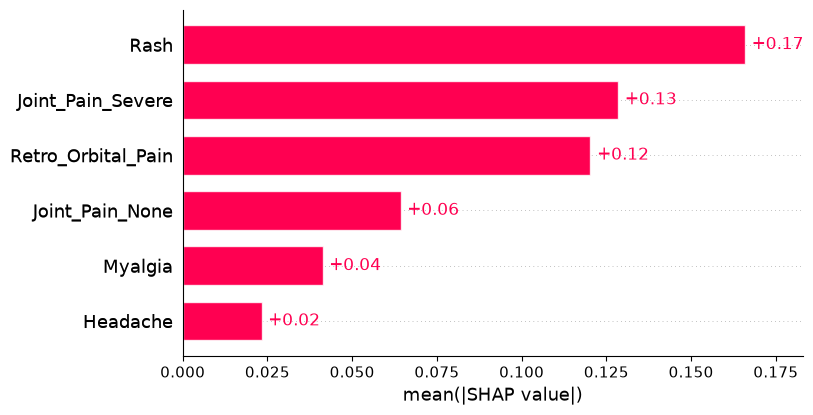

In [112]:
initjs()

X_train_shap = X_train_sel.astype(np.float64)
X_val_shap = X_val_sel.astype(np.float64)

# Use the whole training set as background instead of the default 100-row subsample.
background = maskers.Independent(X_train_shap, max_samples=X_train_shap.shape[0])

# Explain the positive-class probability for the binary classifier.
explainer = Explainer(
    lambda data: lime_model.predict_proba(pd.DataFrame(data, columns=feature_names))[:, 1],
    background,
    feature_names=feature_names,
    seed=RANDOM_STATE,
    max_evals=2 * X_train_shap.shape[1] + 1,
    silent=True,
    algorithm='permutation',
)
shap_values = explainer(X_val_shap)

plots.bar(shap_values, max_display=14)


Actual values: 0


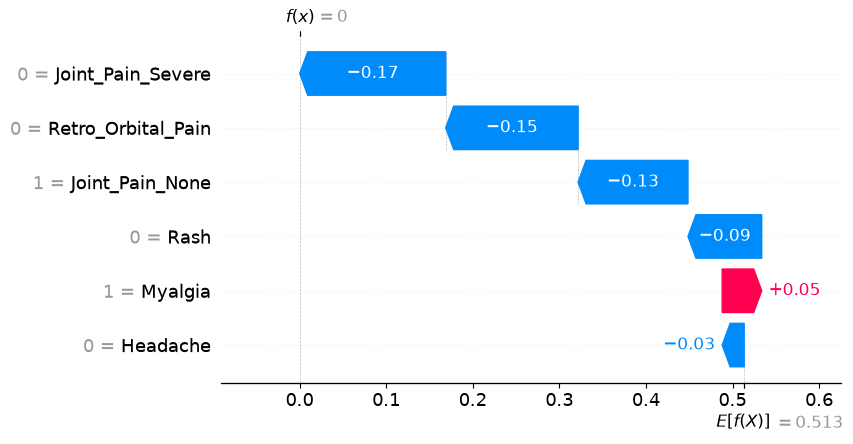

In [113]:
index = 19
print(f'Actual values: {y_val.iloc[index]}')
plots.waterfall(shap_values[index], max_display=14)

Actual values: 0


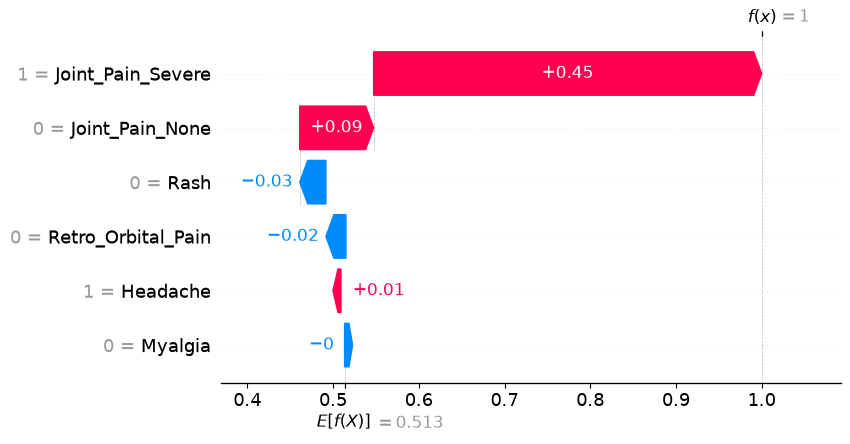

In [168]:
index = 44

print(f'Actual values: {y_val.iloc[index]}')
plots.waterfall(shap_values[index], max_display=14)

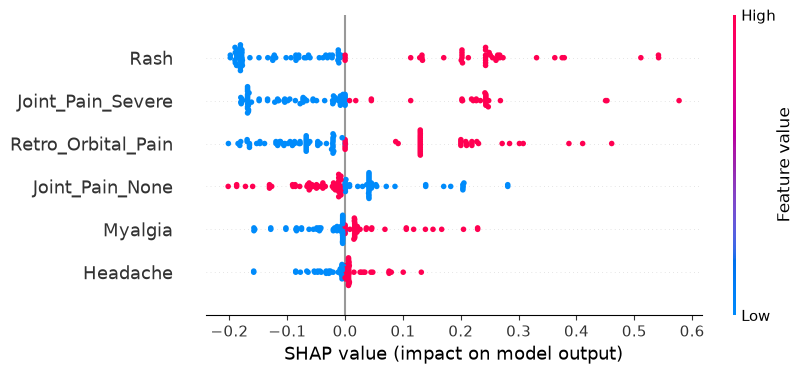

In [115]:
plots.beeswarm(shap_values, max_display=14)